Análise exploratória  da query 2: Questões a responder

Objetivo: Analisar salários e distribuição geográfica (Cidade, Estado ou País). 

In [20]:
# 1. Importamos as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [21]:
# 2. Carregar os dados da Query 2
df_query2 = pd.read_csv('CSV_da_query_2.csv')
print('base de dados carregada!')

base de dados carregada!


In [22]:
# 3. Visualização Inicial dos Dados
print("Query 2 - primeiras linhas:")
df_query2.head()

Query 2 - primeiras linhas:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,CITY,COUNTRY_NAME,REGION_NAME
0,100,Steven,King,24000,Executive,Seattle,United States of America,Americas
1,102,Lex,Garcia,17000,Executive,Seattle,United States of America,Americas
2,101,Neena,Yang,17000,Executive,Seattle,United States of America,Americas
3,145,John,Singh,14000,Sales,Oxford,United Kingdom of Great Britain and Northern I...,Europe
4,146,Karen,Partners,13500,Sales,Oxford,United Kingdom of Great Britain and Northern I...,Europe


In [23]:
# 3.1 Visualização Inicial dos Dados - Informações gerais
print("Informações gerais do DataFrame:")
df_query2.info()

Informações gerais do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EMPLOYEE_ID      107 non-null    int64
 1   FIRST_NAME       107 non-null    str  
 2   LAST_NAME        107 non-null    str  
 3   SALARY           107 non-null    int64
 4   DEPARTMENT_NAME  106 non-null    str  
 5   CITY             106 non-null    str  
 6   COUNTRY_NAME     106 non-null    str  
 7   REGION_NAME      106 non-null    str  
dtypes: int64(2), str(6)
memory usage: 6.8 KB


In [24]:
# 4. Estatísticas descritivas do salário geral
print("\n📌 Estatísticas descritivas do salário:")
print(df_query2['SALARY'].describe().round(2))


📌 Estatísticas descritivas do salário:
count      107.00
mean      6461.83
std       3909.58
min       2100.00
25%       3100.00
50%       6200.00
75%       8900.00
max      24000.00
Name: SALARY, dtype: float64


In [25]:
# 5. Contagem de funcionários 

# Por país

contagem_pais = df_query2['COUNTRY_NAME'].value_counts()
print("\n📊 Distribuição de funcionários por país:")
print(contagem_pais)


📊 Distribuição de funcionários por país:
COUNTRY_NAME
United States of America                                68
United Kingdom of Great Britain and Northern Ireland    35
Canada                                                   2
Germany                                                  1
Name: count, dtype: int64


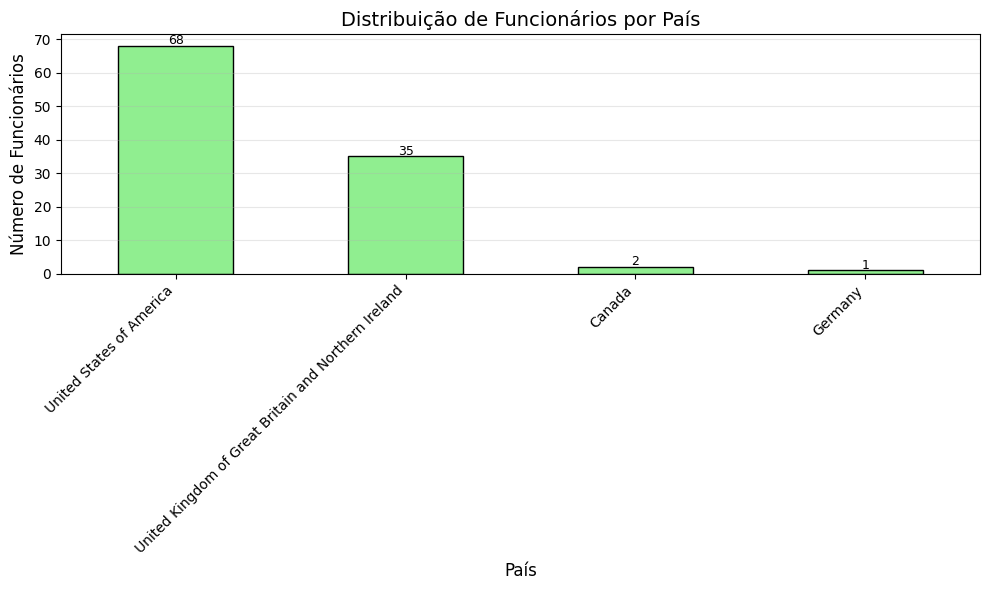

In [26]:
# Gráfico de barras da distribuição de funcionários por país

contagem_pais = df_query2['COUNTRY_NAME'].value_counts()

plt.figure(figsize=(10, 6))
contagem_pais.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribuição de Funcionários por País', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Número de Funcionários', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores em cima das barras
for i, v in enumerate(contagem_pais):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Por região

contagem_regiao = df_query2['REGION_NAME'].value_counts()
print("\n📊 Distribuição de funcionários por região:")
print(contagem_regiao)


📊 Distribuição de funcionários por região:
REGION_NAME
Americas    70
Europe      36
Name: count, dtype: int64


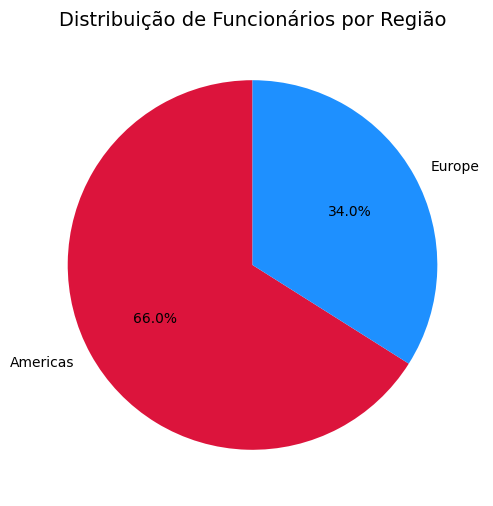

In [28]:
# Gráfico de pizza da distribuição de funcionários por região

contagem_regiao = df_query2['REGION_NAME'].value_counts()

# Cores personalizadas por continente
cores = []
for regiao in contagem_regiao.index:
    if 'Americas' in regiao:
        cores.append('#DC143C')  # vermelho carmesim
    elif 'Europe' in regiao:
        cores.append('#1E90FF')  # azul dodger
plt.figure(figsize=(6, 6))
plt.pie(
    contagem_regiao,
    labels=contagem_regiao.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores
)
plt.title('Distribuição de Funcionários por Região', fontsize=14)
plt.show()

In [29]:
# Por cidade

contagem_cidade = df_query2['CITY'].value_counts()
print("\n📊 Distribuição de funcionários por cidade (Top 10):")
print(contagem_cidade)


📊 Distribuição de funcionários por cidade (Top 10):
CITY
South San Francisco    45
Oxford                 34
Seattle                18
Southlake               5
Toronto                 2
Munich                  1
London                  1
Name: count, dtype: int64


In [30]:
# 6. Estatísticas do salário

# Média salarial por país
media_pais = df_query2.groupby('COUNTRY_NAME')['SALARY'].mean().sort_values(ascending=False).round(2)
print("\n📊 Média salarial por país (Top 10):")
print(media_pais.head(10))


📊 Média salarial por país (Top 10):
COUNTRY_NAME
Germany                                                 10000.00
Canada                                                   9500.00
United Kingdom of Great Britain and Northern Ireland     8885.71
United States of America                                 5064.94
Name: SALARY, dtype: float64


In [31]:
# Média salarial por região
media_regiao = df_query2.groupby('REGION_NAME')['SALARY'].mean().sort_values(ascending=False).round(2)
print("\n📊 Média salarial por região:")
print(media_regiao)


📊 Média salarial por região:
REGION_NAME
Europe      8916.67
Americas    5191.66
Name: SALARY, dtype: float64


C:\Users\miran\AppData\Local\Temp\ipykernel_4928\2472350088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='REGION_NAME', y='SALARY', data=df_query2, palette=['#DC143C', '#1E90FF'])


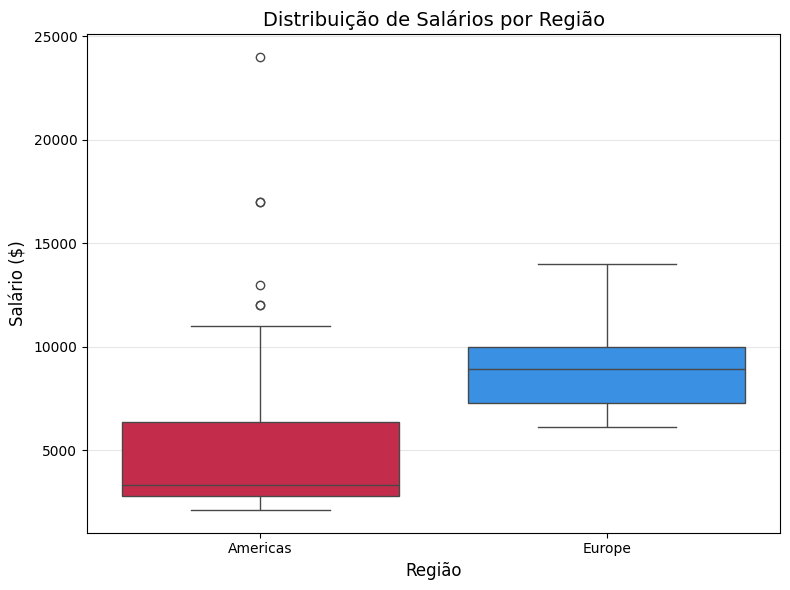

In [32]:
# Boxplot - Distribuição de salários por região

plt.figure(figsize=(8, 6))
sns.boxplot(x='REGION_NAME', y='SALARY', data=df_query2, palette=['#DC143C', '#1E90FF'])
plt.title('Distribuição de Salários por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Salário ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Média salarial por cidade
media_cidade = df_query2.groupby('CITY')['SALARY'].mean().sort_values(ascending=False).round(2)
print("\n📊 Média salarial por cidade (Top 10):")
print(media_cidade)


📊 Média salarial por cidade (Top 10):
CITY
Munich                 10000.00
Toronto                 9500.00
Oxford                  8955.88
Seattle                 8845.33
London                  6500.00
Southlake               5760.00
South San Francisco     3475.56
Name: SALARY, dtype: float64


In [34]:
# 7. Estatísticas descritivas do salário

# Por país

estatisticas_country = df_query2.groupby('COUNTRY_NAME')['SALARY'].agg(
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max',
    desvio_padrao='std',
    contagem='count'
).round(2)

estatisticas_country = estatisticas_country.sort_values('media', ascending=False).round(2)

print("="*60)
print("ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR PAÍS")
print("="*60)
print(estatisticas_country)


ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR PAÍS
                                                       media  mediana  minimo  \
COUNTRY_NAME                                                                    
Germany                                             10000.00  10000.0   10000   
Canada                                               9500.00   9500.0    6000   
United Kingdom of Great Britain and Northern Ir...   8885.71   8800.0    6100   
United States of America                             5064.94   3250.0    2100   

                                                    maximo  desvio_padrao  \
COUNTRY_NAME                                                                
Germany                                              10000            NaN   
Canada                                               13000        4949.75   
United Kingdom of Great Britain and Northern Ir...   14000        2046.11   
United States of America                             24000        4021.88   

      

In [35]:
# Por região

estatisticas_regiao = df_query2.groupby('REGION_NAME')['SALARY'].agg(
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max',
    desvio_padrao='std',
    contagem='count'
).round(2)

estatisticas_regiao = estatisticas_regiao.sort_values('media', ascending=False).round(2)

print("="*60)
print("ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR REGIÃO")
print("="*60)
print(estatisticas_regiao)

ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR REGIÃO
               media  mediana  minimo  maximo  desvio_padrao  contagem
REGION_NAME                                                           
Europe       8916.67   8900.0    6100   14000        2025.20        36
Americas     5191.66   3300.0    2100   24000        4076.22        70


In [36]:
# Por cidade

estatisticas_cidade = df_query2.groupby('CITY')['SALARY'].agg(
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max',
    desvio_padrao='std',
    contagem='count'
).round(2)

estatisticas_cidade = estatisticas_cidade.sort_values('media', ascending=False).round(2)

print("="*60)
print("ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR CIDADE")
print("="*60)
print(estatisticas_cidade)

ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR CIDADE
                        media  mediana  minimo  maximo  desvio_padrao  \
CITY                                                                    
Munich               10000.00  10000.0   10000   10000            NaN   
Toronto               9500.00   9500.0    6000   13000        4949.75   
Oxford                8955.88   8900.0    6100   14000        2033.68   
Seattle               8845.33   8000.0    2500   24000        5931.80   
London                6500.00   6500.0    6500    6500            NaN   
Southlake             5760.00   4800.0    4200    9000        1925.62   
South San Francisco   3475.56   3100.0    2100    8200        1488.01   

                     contagem  
CITY                           
Munich                      1  
Toronto                     2  
Oxford                     34  
Seattle                    18  
London                      1  
Southlake                   5  
South San Francisco        45  


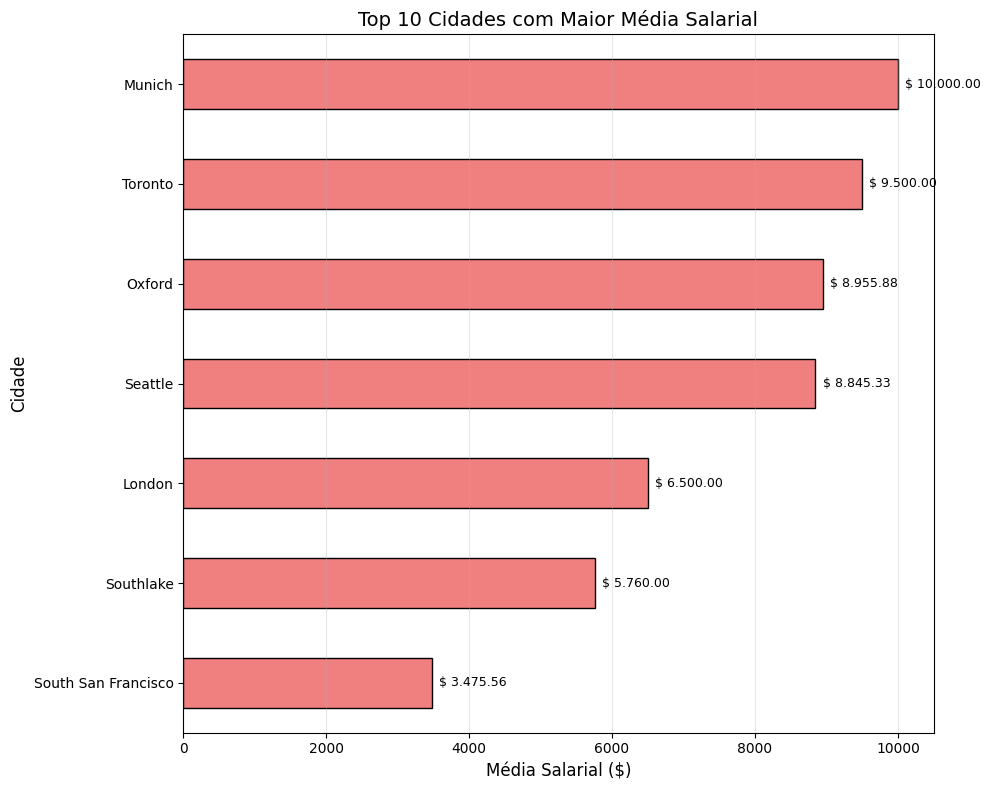

In [37]:
# Média salarial por cidade (Top 10) - Gráfico de barras horizontal

media_cidade = df_query2.groupby('CITY')['SALARY'].mean().sort_values(ascending=True).round(2).tail(10)

plt.figure(figsize=(10, 8))
media_cidade.plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title('Top 10 Cidades com Maior Média Salarial', fontsize=14)
plt.xlabel('Média Salarial ($)', fontsize=12)
plt.ylabel('Cidade', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores ao lado das barras
for i, v in enumerate(media_cidade.values):
    plt.text(v + 100, i, f'$ {v:,.2f}'.replace(',', '.'), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
#### 8. Conclusões da análise - Query 2

print("="*60)
print("CONCLUSÕES DA ANÁLISE - QUERY 2")
print("="*60)

print(f"""
📊 PRINCIPAIS INSIGHTS:

1. PAÍS COM MAIOR MÉDIA SALARIAL:
   - {estatisticas_country['media'].idxmax()}: US$ {estatisticas_country['media'].max():.2f}

2. PAÍS COM MENOR MÉDIA SALARIAL:
   - {estatisticas_country['media'].idxmin()}: US$ {estatisticas_country['media'].min():.2f}

3. REGIÃO COM MAIOR MÉDIA SALARIAL:
   - {estatisticas_regiao['media'].idxmax()}: US$ {estatisticas_regiao['media'].max():.2f}

4. REGIÃO COM MENOR MÉDIA SALARIAL:
   - {estatisticas_regiao['media'].idxmin()}: US$ {estatisticas_regiao['media'].min():.2f}

5. CIDADE COM MAIOR MÉDIA SALARIAL:
   - {estatisticas_cidade['media'].idxmax()}: US$ {estatisticas_cidade['media'].max():.2f}

6. CIDADE COM MENOR MÉDIA SALARIAL:
   - {estatisticas_cidade['media'].idxmin()}: US$ {estatisticas_cidade['media'].min():.2f}

7. PAÍS COM MAIS FUNCIONÁRIOS:
   - {estatisticas_country['contagem'].idxmax()}: {estatisticas_country['contagem'].max()} funcionários

8. CIDADE COM MAIS FUNCIONÁRIOS:
   - {estatisticas_cidade['contagem'].idxmax()}: {estatisticas_cidade['contagem'].max()} funcionários

9. TOTAL DE FUNCIONÁRIOS ANALISADOS:
   - {len(df_query2)} funcionários

🔍 OBSERVAÇÕES RELEVANTES:
   - A Europa apresenta salários mais elevados e distribuição mais homogênea (mediana de US$ 8.900), enquanto as Américas têm maior variabilidade e salários mais baixos (mediana de US$ 3.300), com presença de outliers na faixa superior (acima de US$ 20.000).
   - Oxford se destaca como polo de alta remuneração, com 34 funcionários e média de US$ 8.955,88, enquanto South San Francisco, apesar de ter o maior número de colaboradores (45), possui a menor média salarial.
   - As diferenças salariais entre regiões sugerem a necessidade de revisão das políticas de remuneração para garantir equidade e competitividade.
""")

CONCLUSÕES DA ANÁLISE - QUERY 2

📊 PRINCIPAIS INSIGHTS:

1. PAÍS COM MAIOR MÉDIA SALARIAL:
   - Germany: US$ 10000.00

2. PAÍS COM MENOR MÉDIA SALARIAL:
   - United States of America: US$ 5064.94

3. REGIÃO COM MAIOR MÉDIA SALARIAL:
   - Europe: US$ 8916.67

4. REGIÃO COM MENOR MÉDIA SALARIAL:
   - Americas: US$ 5191.66

5. CIDADE COM MAIOR MÉDIA SALARIAL:
   - Munich: US$ 10000.00

6. CIDADE COM MENOR MÉDIA SALARIAL:
   - South San Francisco: US$ 3475.56

7. PAÍS COM MAIS FUNCIONÁRIOS:
   - United States of America: 68 funcionários

8. CIDADE COM MAIS FUNCIONÁRIOS:
   - South San Francisco: 45 funcionários

9. TOTAL DE FUNCIONÁRIOS ANALISADOS:
   - 107 funcionários

🔍 OBSERVAÇÕES RELEVANTES:
   - A Europa apresenta salários mais elevados e distribuição mais homogênea (mediana de US$ 8.900), enquanto as Américas têm maior variabilidade e salários mais baixos (mediana de US$ 3.300), com presença de outliers na faixa superior (acima de US$ 20.000).
   - Oxford se destaca como polo de alt